## 신경망 초기 모델 퍼셉트론의 한계, XOR 연산
* sklearn 구현
* XOR 구현 sklearn
* XOR 구현 numpy 이용

In [1]:
import numpy as np
# 행렬 연산 라이브러리 불러오기
import matplotlib.pyplot as plt
# 데이터 시각화 라이브러리 불러오기
from typing import *
# 자료형 어노테이션 선언 라이브러리 불러오기
from sklearn.linear_model import Perceptron
# 사이킷런에서 퍼셉트론 라이브러리 불러오기

### 1. 퍼셉트론 AND Gate scikit-learn 구현

In [2]:
X = np.array([
    [0,0], [0,1], [1,0], [1,1] ])
# 입력 데이터: AND 게이트의 4가지 입력 조합(x_1, x_2)
y = np.array([0,0,0,1])
# 정답 레이블: 둘 다 1일때만 1

In [3]:
clf = Perceptron(tol = 1e-3, random_state = 0)
# 퍼셉트론 객체 clf 생성
# tol: 손실 개선폭이 tolerance 값보다 작으면 학습 조기 종료시키는 기준
# random_state: 가중치 초기화, 난수 시드 고정

clf.fit(X, y)
# 입력 X와 정답 y로 가중치(W)와 편향(b)를 자동으로 학습

print(clf.predict(X))
# 학습된 모델로 같은 입력을 예측 → [0 0 0 1] 출력

[0 0 0 1]


### 2.1. 퍼셉트론 XOR scikit-learn 구현

In [4]:
y_xor = np.array([0,1,1,0])
# 정답 레이블: 두 입력이 다를 때만 1

clf_xor = Perceptron(tol = 1e-3, random_state = 0)
clf_xor.fit(X, y_xor)
print(clf_xor.predict(X))          
# [0 0 0 0] → 정답 [0 1 1 0]과 다름

[0 0 0 0]


### 2.2. 퍼셉트론 AND 게이트 및 XOR 게이트 결정 경계 시각화

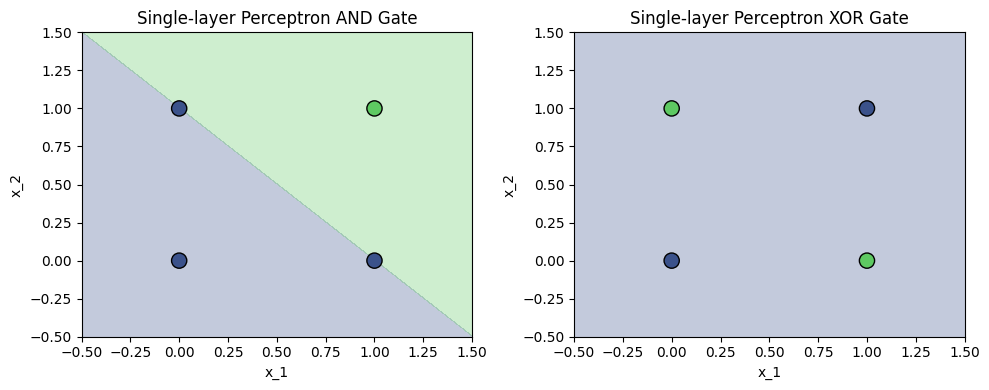

In [10]:
xx, yy = np.meshgrid( np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200) )
# x_1, x_2을 -0.5 ~ 1.5 범위에서 200개씩 나누어 격자 200 by 200 좌표 생성
# 0과 1 주변을 여유있게 보이도록 범위 설정
grid = np.c_[ xx.ravel(), yy.ravel() ]
# 격자 좌표 1차원으로 펼쳐, (x_1, x_2)로 묶음
# 모델의 예측값 predict에 넣을 수 있는 입력 형태로 변환

fig, axes = plt.subplots(1, 2, figsize = (10, 4))
# 1행 2열 그래프 생성, 왼쪽은 AND 게이트, 오른쪽은 XOR 게이트 

for ax, model, labels, title in zip(
    axes, 
    [clf, clf_xor], 
    [y, y_xor],
    ["Single-layer Perceptron AND Gate", "Single-layer Perceptron XOR Gate"]):

    zz = model.predict(grid).reshape(xx.shape)
    # 격자의 모든 점을 예측(0 또는 1)한 뒤 격자 모양 (200×200)으로 되돌림

    ax.contourf(xx, yy, zz, alpha = 0.3, levels = [-0.5, 0.5, 1.5])
    # 예측 클래스별로 배경 영역을 색칠 
    # alpha: 투명도 설정, levels: 0 이하 / 1 이상 두 구간으로 나눠 클래스 0, 1 영역을 구분

    ax.scatter(X[:, 0], X[:, 1], c = labels, 
               s = 120, edgecolors = "k", vmin = -0.5, vmax = 1.5)
    # 실제 입력 4개 점을 정답 레이블 색으로 표시 (s: 점 크기, edgecolors: 테두리 검정)

    ax.set_title(title)
    ax.set_xlabel("x_1"); ax.set_ylabel("x_2")
    # 그래프 제목 및 축 이름 설정

plt.tight_layout()
# 그래프 간 간격, 여백 자동 조정
plt.show()

### 3. 퍼셉트론 XOR numpy 구현

* 곱하고, 더하고, 활성화시키는 과정의 연속

In [5]:
class SingleLayerPerceptron:
    """퍼셉트론 연산 클래스"""

    def __init__(self, X: np.array, y: np.array, eta: float, epochs = 10):
        """
        Args:
            - X: 훈련 데이터
            - y: 정답 데이터
            - W: 가중치 행렬
            - eta: 학습률(learningRate), 가중치를 한 번에 얼마나 조정할지 결정
            - epochs: 가중치를 업데이트하기 위해 전체 훈련 데이터를 학습시키는 과정의 횟수
        """
        self.X = X
        self.y = y
        self.W = np.zeros( len(X[0]) )
        self.eta = eta
        self.epochs = epochs

    @staticmethod
    def activationFunction(t):
        """퍼셉트론의 입력을 받아 뉴런을 활성화시키는 계단 함수 메서드"""
        if t > 0 : return 1
        # 가중치와 입력의 내적에 편향을 더한 값(t)이 0보다 크면 1로 예측
        # 정답이 1일 때, 예측이 1이어야 종료
        else : return 0
        # t가 0보다 작거나 같을 경우 0으로 예측

    def fit(self):
        """퍼셉트론 학습 알고리즘 메서드"""
        for t in range(self.epochs):
            # 전체 데이터셋을 에폭 횟수만큼 반복 학습
            print("epoch = ", t, "====================")
            # 현재 몇 번째 epoch인지 출력

            for i in range( len(self.X) ):
            # 학습 데이터 순회
                y_predict = self.activationFunction(
                   t = np.dot(self.X[i], self.W) )
                # 입력과 가중치의 내적을 계단 함수에 넣어 예측값(0 또는 1)을 구함
                error = self.y[i] - y_predict
                # 정답 배열(Y[i])에서 예측값을 뺀 오차 계산 (-1, 0, 1 중 하나)
                self.W += self.eta * error * self.X[i]
                # 퍼셉트론 학습 규칙
                # 오차가 있을 때만 가중치를 입력값 방향으로 학습률만큼 조정하여 가중치 업데이트 
                print(
                    "현재 처리 입력 = ", self.X[i], 
                    "정답 = ", self.y[i], 
                    "출력 = ", y_predict, 
                    "변경된 가중치 = ", self.W
                )
                # 학습 과정을 한 샘플마다 출력

        print("================================")
        # 해당 epoch 종료 구분선 출력
        
    def predict(self):
        """퍼셉트론 예측 알고리즘 메서드"""
        for x in self.X:
        # 예측할 입력 데이터 순회
            print(
                x[0], x[1], "→", self.activationFunction(np.dot(x, self.W))
            )
            # 두 입력값과 그에 대한 퍼셉트론 출력 결과 반환

In [6]:
# [TO-BE] 단층 퍼셉트론 XOR Operation → 수렴하지 않음
perceptron_XOR = SingleLayerPerceptron(
    X = np.array([
        [0,0,1], [0,1,1], [1,0,1], [1,1,1] ]), # x_1, x_2, 1(b = w_0 = 1)
    y = np.array(
        [0,1,1,0]), # 정답 레이블: 두 입력이 다를 때만 1
    eta = 0.2,
    epochs = 6
)
perceptron_XOR.fit()
perceptron_XOR.predict()
# 출력이 [0,1,1,0]이 되지 않음 → 선형 분리 불가능
# epoch를 늘려도 가중치가 같은 자리에서 맴돌고 정답을 맞추지 못함
# 즉, 단층 퍼셉트론은 직선 하나로 XOR을 나눌 수 없으므로 학습이 불가함

epoch =  0 ====================
현재 처리 입력 =  [0 0 1] 정답 =  0 출력 =  0 변경된 가중치 =  [0. 0. 0.]
현재 처리 입력 =  [0 1 1] 정답 =  1 출력 =  0 변경된 가중치 =  [0.  0.2 0.2]
현재 처리 입력 =  [1 0 1] 정답 =  1 출력 =  1 변경된 가중치 =  [0.  0.2 0.2]
현재 처리 입력 =  [1 1 1] 정답 =  0 출력 =  1 변경된 가중치 =  [-0.2  0.   0. ]
epoch =  1 ====================
현재 처리 입력 =  [0 0 1] 정답 =  0 출력 =  0 변경된 가중치 =  [-0.2  0.   0. ]
현재 처리 입력 =  [0 1 1] 정답 =  1 출력 =  0 변경된 가중치 =  [-0.2  0.2  0.2]
현재 처리 입력 =  [1 0 1] 정답 =  1 출력 =  0 변경된 가중치 =  [0.  0.2 0.4]
현재 처리 입력 =  [1 1 1] 정답 =  0 출력 =  1 변경된 가중치 =  [-0.2  0.   0.2]
epoch =  2 ====================
현재 처리 입력 =  [0 0 1] 정답 =  0 출력 =  1 변경된 가중치 =  [-0.2  0.   0. ]
현재 처리 입력 =  [0 1 1] 정답 =  1 출력 =  0 변경된 가중치 =  [-0.2  0.2  0.2]
현재 처리 입력 =  [1 0 1] 정답 =  1 출력 =  0 변경된 가중치 =  [0.  0.2 0.4]
현재 처리 입력 =  [1 1 1] 정답 =  0 출력 =  1 변경된 가중치 =  [-0.2  0.   0.2]
epoch =  3 ====================
현재 처리 입력 =  [0 0 1] 정답 =  0 출력 =  1 변경된 가중치 =  [-0.2  0.   0. ]
현재 처리 입력 =  [0 1 1] 정답 =  1 출력 =  0 변경된 가중치 =  [-0.2  0.2 

In [7]:
# [AS-IS] 단층 퍼셉트론 AND Gate → 수렴함
perceptron_AND = SingleLayerPerceptron(
    X = np.array([
        [0,0,1], [0,1,1], [1,0,1], [1,1,1] ]), # x_1, x_2, 1(b = w_0 = 1)
    y = np.array(
        [0,0,0,1]), # 정답 레이블: 둘 다 1일때만 1
    eta = 0.2,
    epochs = 6
)
perceptron_AND.fit()
perceptron_AND.predict()
# [0 0 0 1] 출력

epoch =  0 ====================
현재 처리 입력 =  [0 0 1] 정답 =  0 출력 =  0 변경된 가중치 =  [0. 0. 0.]
현재 처리 입력 =  [0 1 1] 정답 =  0 출력 =  0 변경된 가중치 =  [0. 0. 0.]
현재 처리 입력 =  [1 0 1] 정답 =  0 출력 =  0 변경된 가중치 =  [0. 0. 0.]
현재 처리 입력 =  [1 1 1] 정답 =  1 출력 =  0 변경된 가중치 =  [0.2 0.2 0.2]
epoch =  1 ====================
현재 처리 입력 =  [0 0 1] 정답 =  0 출력 =  1 변경된 가중치 =  [0.2 0.2 0. ]
현재 처리 입력 =  [0 1 1] 정답 =  0 출력 =  1 변경된 가중치 =  [ 0.2  0.  -0.2]
현재 처리 입력 =  [1 0 1] 정답 =  0 출력 =  0 변경된 가중치 =  [ 0.2  0.  -0.2]
현재 처리 입력 =  [1 1 1] 정답 =  1 출력 =  0 변경된 가중치 =  [0.4 0.2 0. ]
epoch =  2 ====================
현재 처리 입력 =  [0 0 1] 정답 =  0 출력 =  0 변경된 가중치 =  [0.4 0.2 0. ]
현재 처리 입력 =  [0 1 1] 정답 =  0 출력 =  1 변경된 가중치 =  [ 0.4  0.  -0.2]
현재 처리 입력 =  [1 0 1] 정답 =  0 출력 =  1 변경된 가중치 =  [ 0.2  0.  -0.4]
현재 처리 입력 =  [1 1 1] 정답 =  1 출력 =  0 변경된 가중치 =  [ 0.4  0.2 -0.2]
epoch =  3 ====================
현재 처리 입력 =  [0 0 1] 정답 =  0 출력 =  0 변경된 가중치 =  [ 0.4  0.2 -0.2]
현재 처리 입력 =  [0 1 1] 정답 =  0 출력 =  0 변경된 가중치 =  [ 0.4  0.2 -0.2]
현재 처리 